In [1]:
import numpy as np 
import copy
import matplotlib.pyplot as plt
import sklearn
import sklearn.linear_model

In [ ]:
def generate_flower_dataset(m=400, random_seed=1):
    np.random.seed(random_seed)

    N = m // 2
    D = 2

    X = np.zeros((m, D))
    Y = np.zeros((m, 1), dtype='uint8')

    a = 4

    for j in range(2):
        ix = range(N*j, N*(j+1))

        t = np.linspace(j*3.12, (j+1)*3.12, N)
        t += np.random.randn(N) * 0.2

        r = a * np.sin(4*t)
        r += np.random.randn(N) * 0.2

        X[ix] = np.c_[r*np.sin(t), r*np.cos(t)]
        Y[ix] = j

    return X.T, Y.T

In [ ]:
X, Y = generate_flower_dataset()

print(X.shape)
print(Y.shape)

(2, 400)
(1, 400)


In [4]:
clf = sklearn.linear_model.LogisticRegressionCV()
clf.fit(X.T,Y.T)

C:\Users\SUYASH\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,Cs,10
,fit_intercept,True
,cv,None
,dual,False
,penalty,'l2'
,scoring,None
,solver,'lbfgs'
,tol,0.0001
,max_iter,100
,class_weight,None
,n_jobs,None


In [10]:
def plot_decision_boundary(model, X, Y):
    
    x_min, x_max = X[0, :].min() - 1, X[0, :].max() + 1
    y_min, y_max = X[1, :].min() - 1, X[1, :].max() + 1
    
    h = 0.01

    XX, YY = np.meshgrid(
        np.arange(x_min, x_max, h),
        np.arange(y_min, y_max, h)
    )

    grid = np.c_[XX.ravel(), YY.ravel()]

    Z = model(grid)

    Z = Z.reshape(XX.shape)

    plt.contourf(XX, YY, Z, alpha=0.5)
    plt.scatter(
        X[0, :],
        X[1, :],
        c=Y.reshape(-1),
        edgecolors='k'
    )
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.show()

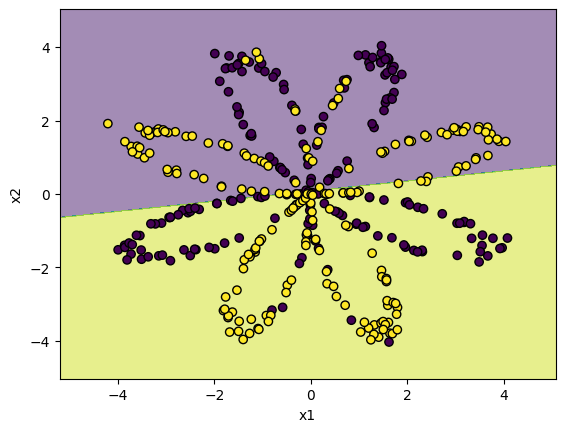

Accuracy of logistic regression: 47 % (percentage of correctly labelled datapoints)


C:\Users\SUYASH\AppData\Local\Temp\ipykernel_27188\472185624.py:9: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print ('Accuracy of logistic regression: %d ' % float((np.dot(Y,LR_predictions) + np.dot(1-Y,1-LR_predictions))/float(Y.size)*100) +


In [11]:
# Plot the decision boundary for logistic regression
plot_decision_boundary(
    lambda x: clf.predict(x),
    X,
    Y
)
# Print accuracy
LR_predictions = clf.predict(X.T)
print ('Accuracy of logistic regression: %d ' % float((np.dot(Y,LR_predictions) + np.dot(1-Y,1-LR_predictions))/float(Y.size)*100) +
       '% ' + "(percentage of correctly labelled datapoints)")

**Interpretation**: The dataset is not linearly separable, so logistic regression doesn't perform well. Hopefully a neural network will do better. Let's try this now! 

In [ ]:
#Neural Network Model

In [15]:
#define neural network structure
n_x = X.shape[0]
n_h = 4
n_y = Y.shape[0]

In [16]:
print("The size of the input layer is: n_x = " + str(n_x))
print("The size of the hidden layer is: n_h = " + str(n_h))
print("The size of the output layer is: n_y = " + str(n_y))

The size of the input layer is: n_x = 2
The size of the hidden layer is: n_h = 4
The size of the output layer is: n_y = 1


In [17]:
#Initialize model parameters
def initialize_parameters(n_x, n_h, n_y):
    w1 = np.random.randn(n_h, n_x)*0.01
    b1 = np.zeros((n_h,1))
    w2 = np.random.randn(n_y, n_h)*0.01
    b2 = np.zeros((n_y,1))
    
    parameters = {"w1":w1, "b1":b1, "w2":w2, "b2":b2}
    
    return parameters

In [21]:
np.random.seed(2)
parameters = initialize_parameters(n_x, n_h, n_y)
print("W1 = " + str(parameters["w1"]))
print("b1 = " + str(parameters["b1"]))
print("W2 = " + str(parameters["w2"]))
print("b2 = " + str(parameters["b2"]))

W1 = [[-0.00416758 -0.00056267]
 [-0.02136196  0.01640271]
 [-0.01793436 -0.00841747]
 [ 0.00502881 -0.01245288]]
b1 = [[0.]
 [0.]
 [0.]
 [0.]]
W2 = [[-0.01057952 -0.00909008  0.00551454  0.02292208]]
b2 = [[0.]]


In [41]:
#Forward Propagation
def forward_propagation(X, parameters):
    w1 = parameters["w1"]
    b1 = parameters["b1"]
    w2 = parameters["w2"]
    b2 = parameters["b2"]
    
    z1 = np.dot(w1,X)+b1
    a1 = np.tanh(z1)
    z2 = np.dot(w2,a1)+b2
    a2 = 1 / (1 + np.exp(-z2))
    
    assert(a2.shape == (1, X.shape[1]))
    cahce = {"z1":z1,"a1":a1,"z2":z2,"a2":a2}
    
    return a2, cahce

In [42]:
#Compute cost
def compute_cost(a2, Y):
    m = Y.shape[1]
    loss = np.multiply (np.log(a2), Y) + np.multiply(np.log(1-a2),(1-Y))
    cost = -np.sum(loss) / m
    
    cost = float(np.squeeze(cost))
    
    return cost

In [48]:
#Implement backpropagation
def backward_propagation(parameters, cache, X, Y):
    m = X.shape[1]
    w1 = parameters["w1"]
    w2 = parameters["w2"]
    a1 = cache["a1"]
    a2 = cache["a2"]
    
    dz2 = a2 - Y
    dw2 = (1/m) * np.dot(dz2, a1.T)
    db2 = (1/m) * np.sum(dz2, axis=1, keepdims=True)
    
    dz1 = np.dot(w2.T, dz2) * (1 - np.power(a1,2))
    dw1 = (1/m) * np.dot(dz1, X.T)
    db1 = (1/m) * np.sum(dz1, axis=1, keepdims=True)
    
    grads = {"dw1":dw1, "db1":db1, "dw2":dw2,"db2":db2}
    
    return grads

In [53]:
#Update parameters
def update_parameters(parameters, grads, learning_rate=1.2):
    w1 = copy.deepcopy(parameters["w1"])
    b1 = parameters["b1"]
    w2 = copy.deepcopy(parameters["w2"])
    b2 = parameters["b2"]
    
    dw1 = grads["dw1"]
    db1 = grads["db1"]
    dw2 = grads["dw2"]
    db2 = grads["db2"]
    
    w1 = w1 - learning_rate * dw1
    b1 = b1 - learning_rate * db1
    w2 = w2  - learning_rate * dw2
    b2 = b2 - learning_rate * db2
    
    parameters = {"w1":w1, "b1":b1, "w2":w2, "b2":b2}
    
    return parameters

In [54]:
# nn_model : gradient function
def nn_model(X,Y, n_h, num_iterations=10000, print_cost=False):
    np.random.seed(3)
    n_x = layer_sizes(X,Y)[0]
    n_y = layer_sizes(X,Y)[2]
    
    parameters = initialize_parameters(n_x, n_h, n_y)
    
    for i in range (0, num_iterations):
        a2, cache = forward_propagation(X, parameters)
        cost = compute_cost(a2,Y)
        grads = backward_propagation(parameters, cache, X, Y)
        parameters = update_parameters(parameters, grads)
        
        if print_cost and i % 1000 == 0:
            print(f"Cost after iterations {i}: {cost}")
            
    return parameters

In [55]:
#Predict
def predict(parameters, X):
    a2, cache = forward_propagation(X, parameters)
    predictions = (a2>0.5)
    return predictions

Cost after iterations 0: 0.6931621661402946
Cost after iterations 1000: 0.25862506828690457
Cost after iterations 2000: 0.23933351654583138
Cost after iterations 3000: 0.23080163442975746
Cost after iterations 4000: 0.2255280270817635
Cost after iterations 5000: 0.22184467595022694
Cost after iterations 6000: 0.21909438354878738
Cost after iterations 7000: 0.22067653410077182
Cost after iterations 8000: 0.21942825136198874
Cost after iterations 9000: 0.21853119969271753


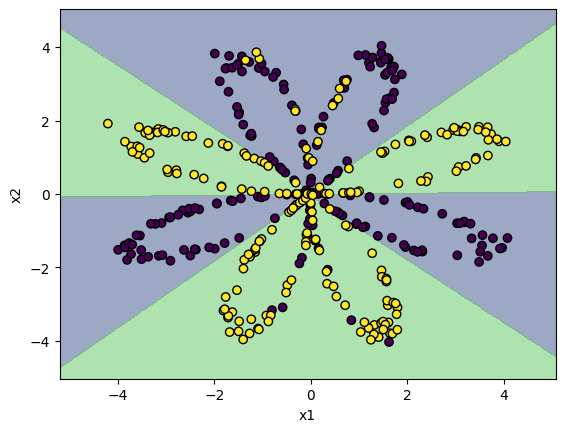

In [57]:
# Build a model with a n_h-dimensional hidden layer
parameters = nn_model(X, Y, n_h = 4, num_iterations = 10000, print_cost=True)

# Plot the decision boundary
plot_decision_boundary(lambda X: predict(parameters, X.T), X, Y)

In [58]:
# Print accuracy
predictions = predict(parameters, X)
print ('Accuracy: %d' % float((np.dot(Y, predictions.T) + np.dot(1 - Y, 1 - predictions.T)) / float(Y.size) * 100) + '%')

Accuracy: 90%


C:\Users\SUYASH\AppData\Local\Temp\ipykernel_27188\1304927518.py:3: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print ('Accuracy: %d' % float((np.dot(Y, predictions.T) + np.dot(1 - Y, 1 - predictions.T)) / float(Y.size) * 100) + '%')


Accuracy is really high compared to Logistic Regression. The model has learned the patterns of the flower's petals! Unlike logistic regression, neural networks are able to learn even highly non-linear decision boundaries. 

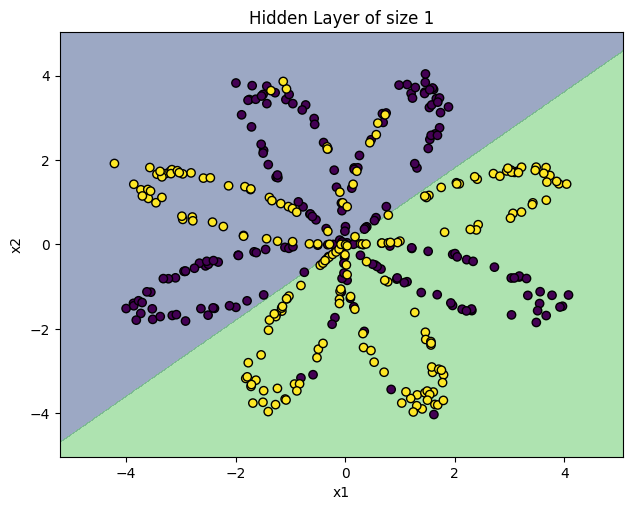

C:\Users\SUYASH\AppData\Local\Temp\ipykernel_27188\1756683585.py:10: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  accuracy = float((np.dot(Y, predictions.T) + np.dot(1-Y, 1-predictions.T))/float(Y.size)*100)


Accuracy for 1 hidden units: 67.5 %


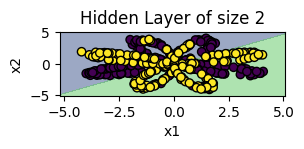

Accuracy for 2 hidden units: 67.25 %


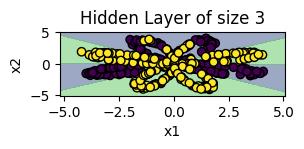

Accuracy for 3 hidden units: 90.75 %


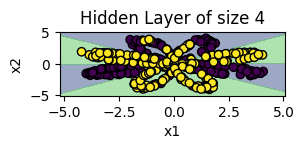

Accuracy for 4 hidden units: 90.5 %


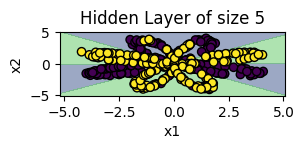

Accuracy for 5 hidden units: 91.25 %


In [61]:
plt.figure(figsize=(16,32))
hidden_layer_sizes = [1,2,3,4,5]

for i, n_h in enumerate(hidden_layer_sizes):
    plt.subplot(5,2,i+1)
    plt.title('Hidden Layer of size %d' % n_h)
    parameters = nn_model(X, Y, n_h, num_iterations=5000)
    plot_decision_boundary(lambda X: predict(parameters, X.T),X,Y)
    predictions = predict(parameters, X)
    accuracy = float((np.dot(Y, predictions.T) + np.dot(1-Y, 1-predictions.T))/float(Y.size)*100)
    print ("Accuracy for {} hidden units: {} %".format(n_h, accuracy))

**Interpretation**:
- The larger models (with more hidden units) are able to fit the training set better, until eventually the largest models overfit the data. 
- The best hidden layer size seems to be around n_h = 5. Indeed, a value around here seems to  fits the data well without also incurring noticeable overfitting.
- Later, you'll become familiar with regularization, which lets you use very large models (such as n_h = 50) without much overfitting. 